Data Loading and Inspection

In [10]:
from google.colab import files

print("Please upload the 'q1_heart_disease.csv' file:")
uploaded = files.upload()

Please upload the 'q1_heart_disease.csv' file:


Saving q1_heart_disease.csv to q1_heart_disease.csv


In [12]:
import pandas as pd

df = pd.read_csv('/content/q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


Exploratory Data Analysis

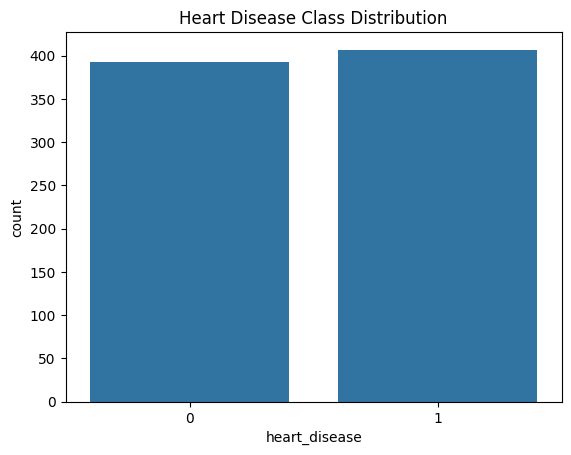

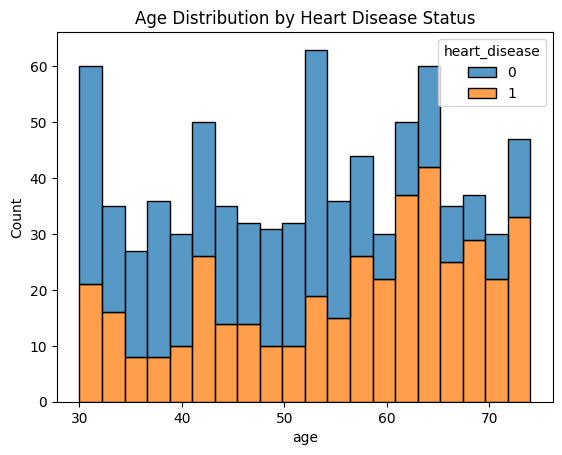

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x="heart_disease", data=df)
plt.title("Heart Disease Class Distribution")
plt.show()

# Age distribution by target
sns.histplot(data=df, x="age", hue="heart_disease", multiple="stack", bins=20)
plt.title("Age Distribution by Heart Disease Status")
plt.show()

Data Preprocessing

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Median imputation for numerical, mode for categorical
for col in df.select_dtypes(include="number").columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(exclude="number").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and target
X = df_encoded.drop("heart_disease", axis=1)
y = df_encoded["heart_disease"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


/tmp/ipykernel_2683/1766435776.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2683/1766435776.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

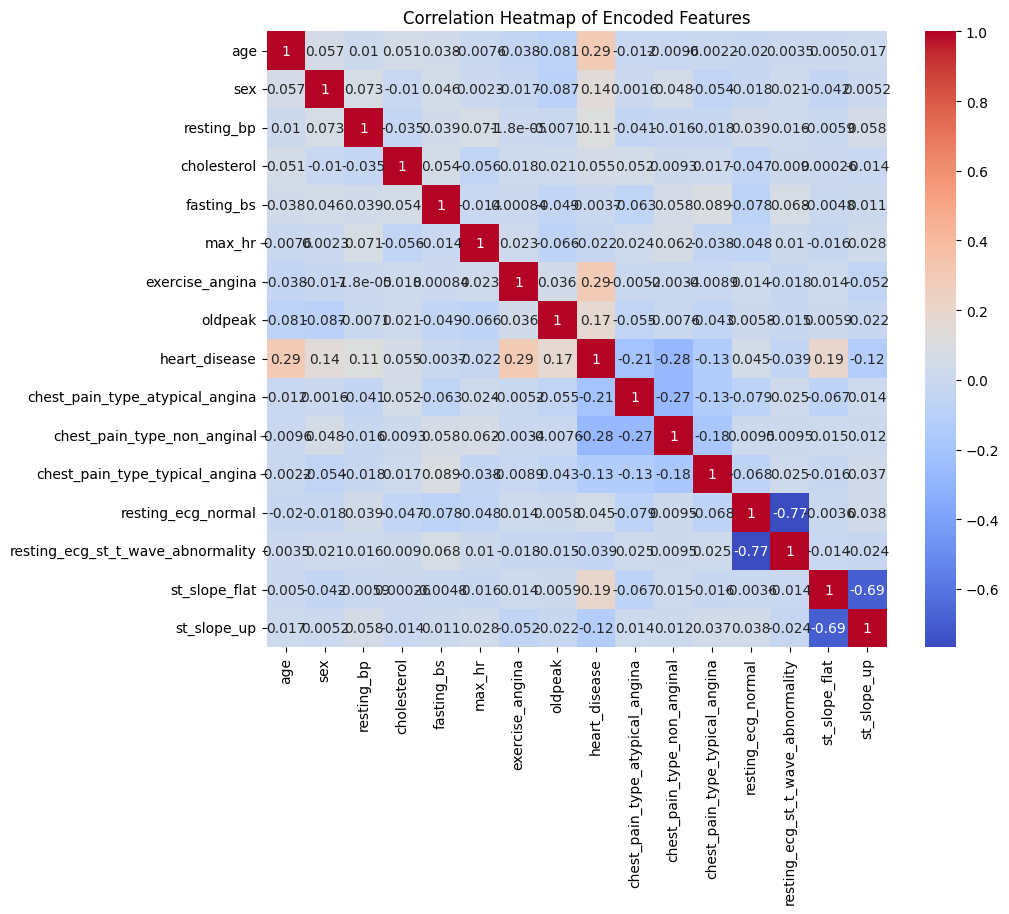

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Encoded Features")
plt.show()

Model Training

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

Model Evaluation

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred_tuned = grid.best_estimator_.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))


Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Confusion Matrix:
 [[60 19]
 [16 65]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77        79
           1       0.77      0.80      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160



Hyperparameter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred_tuned = grid.best_estimator_.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))


Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Confusion Matrix:
 [[60 19]
 [16 65]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77        79
           1       0.77      0.80      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160

